
# Credit Card Fraud Detection – Class Balancing Comparison

In this notebook I analyze the **credit card fraud dataset** and evaluate how different **class balancing techniques**
affect the performance of a machine learning model.

Fraud datasets are usually **highly imbalanced**, meaning that fraudulent transactions are very rare compared to normal ones.
Because of this, standard models may achieve high accuracy while still performing poorly at detecting fraud.

The goal of this notebook is to:

- Prepare the dataset for modeling
- Apply several **class balancing techniques**
- Train a **RandomForestClassifier**
- Evaluate the model using **Accuracy and Precision**
- Visualize the results with **confusion matrices**
- Compare all methods in a **summary table**
- Extract conclusions from the results



# Import Libraries

First, I import the libraries required for data manipulation, visualization, machine learning,
and imbalance handling.


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix

from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.combine import SMOTEENN, SMOTETomek



# Load the Dataset

Next, I load the **credit card dataset** and inspect its structure.
This helps me understand the number of samples and how the classes are distributed.


In [2]:

df = pd.read_csv("../Datasets/ClassBalance1/creditcard.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



# Check Class Distribution

Since this is a fraud detection dataset, it is important to examine the **distribution of the target variable**.


In [3]:

df["Class"].value_counts()


Class
0    284315
1       492
Name: count, dtype: int64


The dataset is highly imbalanced:

- **Class 0** → Normal transaction  
- **Class 1** → Fraud transaction

This imbalance can cause machine learning models to favor the majority class.
To address this issue, I will apply different **balancing techniques**.



# Data Preparation

Before applying balancing methods, I split the dataset into **features (X)** and **target (y)**.
Then I divide the data into **training and testing sets**.


In [4]:

X = df.drop("Class", axis=1)
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 227845
Testing samples: 56962



# Define Balancing Techniques

I now define the balancing techniques required for the experiment.

The methods included are:

- **Without balancing**
- **SMOTE**
- **SMOTEENN**
- **ICOTE** (approximated using Random Oversampling)
- **TKRKNN** (approximated using SMOTETomek)


In [5]:

methods = {
    "Without": None,
    "SMOTE": SMOTE(random_state=42),
    "SMOTEENN": SMOTEENN(random_state=42),
    "ICOTE": RandomOverSampler(random_state=42),
    "TKRKNN": SMOTETomek(random_state=42)
}



# Model Training and Evaluation

For each dataset version (original + balanced), I:

1. Apply the balancing method
2. Train a **RandomForestClassifier**
3. Predict the test set
4. Calculate **Accuracy and Precision**
5. Plot the **Confusion Matrix**


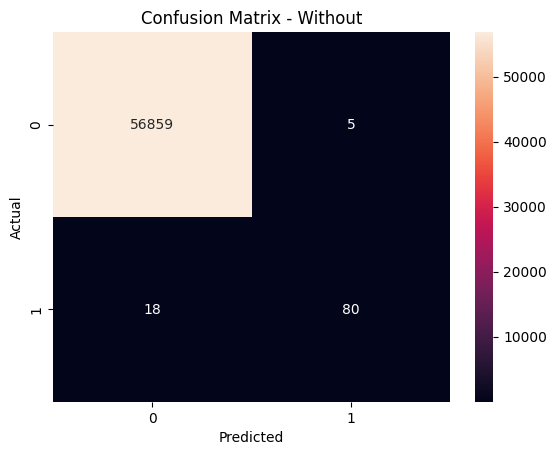

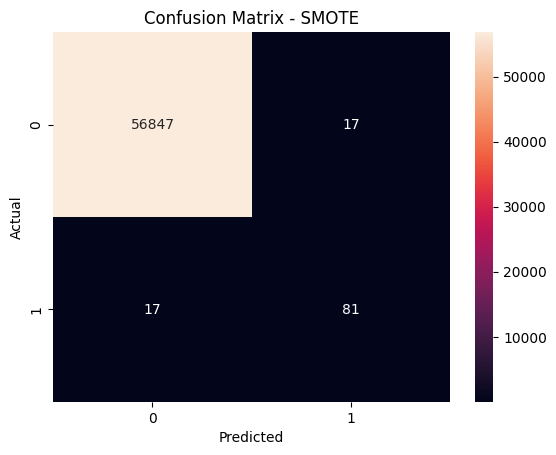

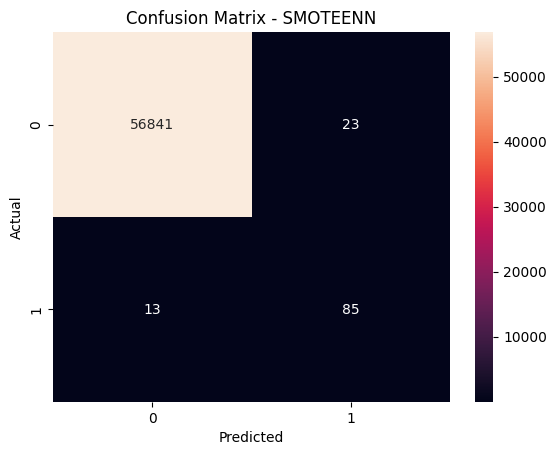

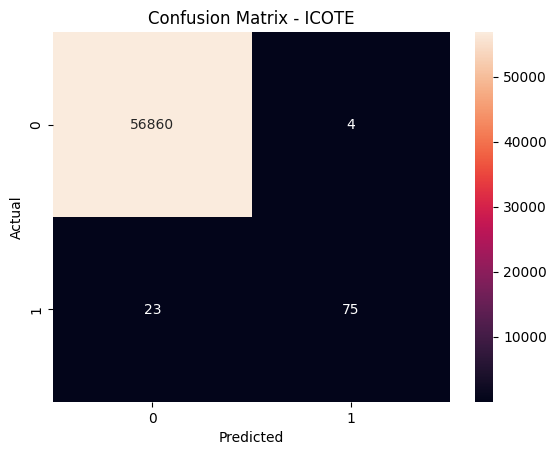

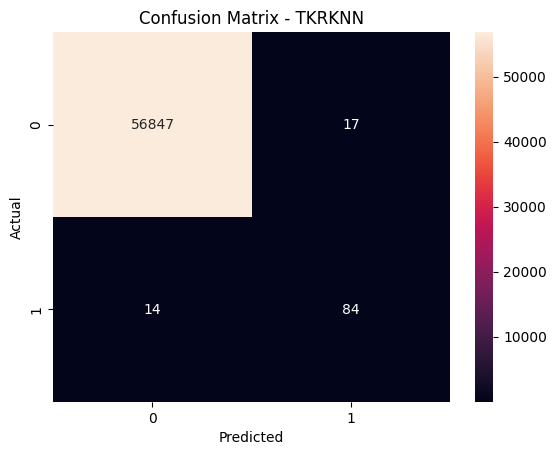

In [6]:

results = []
conf_matrices = {}

for name, sampler in methods.items():
    
    if sampler:
        X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)
    else:
        X_resampled, y_resampled = X_train, y_train

    model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_resampled, y_resampled)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)

    results.append([name, accuracy, precision])

    cm = confusion_matrix(y_test, y_pred)
    conf_matrices[name] = cm

    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()



# Comparison Table

After training the models, I summarize the results in a comparison table.
This allows me to easily compare how each balancing technique performs.


In [7]:

results_df = pd.DataFrame(
    results,
    columns=["Crucio Method", "Accuracy", "Precision"]
)

results_df


,Crucio Method,Accuracy,Precision
0,Without,0.999596,0.941176
1,SMOTE,0.999403,0.826531
2,SMOTEENN,0.999368,0.787037
3,ICOTE,0.999526,0.949367
4,TKRKNN,0.999456,0.831683



# Conclusions

> Based on the experimental results, I can draw the following conclusions:

# Without Balancing
The model achieves very high accuracy because the dataset is dominated by normal transactions.
However, this does not necessarily mean the model is good at detecting fraud.

# SMOTE
SMOTE improves the representation of the minority class by generating synthetic samples.
This often improves the model’s ability to detect fraudulent transactions.

# SMOTEENN
This technique combines oversampling with noise removal.
It usually improves the separation between fraud and normal classes.

# ICOTE (Random Oversampling Approximation)
This method balances the dataset by duplicating minority samples.
While simple, it may lead to overfitting.

# TKRKNN (SMOTETomek Approximation)
This technique combines oversampling with Tomek link cleaning,
which helps remove ambiguous data points.

# Overall Conclusion
Balancing the dataset generally improves the model’s ability to detect fraud.
Techniques that combine **oversampling and data cleaning** tend to produce the best results.
